# UK Online Retail: Customer Intelligence & Revenue Analysis
### A Business Analytics Case Study  ·  UCI Machine Learning Repository Dataset

---

**Analyst:** Portfolio Project  
**Dataset:** UCI Online Retail (541,909 transactions · Dec 2010 – Dec 2011)  
**Tools:** Python · Pandas · Matplotlib · Seaborn  
**Focus:** Customer segmentation, revenue intelligence, purchasing patterns, operational health

---

## Executive Summary

This notebook investigates twelve months of transaction data from a UK-based non-store online retailer specialising in gift merchandise. The business serves a mix of individual consumers and wholesale buyers, which shapes everything from order sizes to return patterns.

Three findings stand out:

1. **Revenue is heavily concentrated.** The top 30% of customers by lifetime value generate roughly 73% of total revenue. This isn't a sign of weakness — it reflects the wholesale channel — but it makes retention of that cohort the single highest-leverage commercial priority.

2. **November is the business.** The Q4 spike is not gradual: revenue roughly doubles between September and November, then drops sharply. A retailer this reliant on a six-week seasonal window carries meaningful demand-timing risk.

3. **A quarter of the customer base is drifting.** The RFM model flags ~759 "At Risk" and ~565 "Lapsed" customers who were historically active but have gone quiet. At an average order value near £480, even a modest win-back rate on this group represents material incremental revenue.

The sections below build each of these findings from first principles — starting with raw data quality and ending with concrete strategic recommendations.

---
## 1. Business Context

The retailer operates entirely online, ships to 37 countries, and carries a catalogue of hundreds of SKUs — most in the £1–£10 unit price range. Because many customers are wholesalers, a single invoice can represent thousands of pounds and hundreds of units of a single SKU. That wholesale dynamic makes conventional "average customer" metrics misleading and RFM segmentation particularly valuable.

The dataset covers **01/12/2010 to 09/12/2011** — 373 days, crossing two Q4 peaks but only one full calendar year of Q1–Q3 data. Any year-on-year comparisons are therefore impossible; the analysis focuses on within-period patterns.

---
## 2. Dataset & Data Dictionary

| Variable | Type | Description |
|---|---|---|
| `InvoiceNo` | String | Unique invoice number. Prefix **C** = cancellation/return |
| `StockCode` | String | Product identifier |
| `Description` | String | Product name |
| `Quantity` | Integer | Units per line item (negative on returns) |
| `InvoiceDate` | Datetime | Transaction timestamp |
| `UnitPrice` | Float | Per-unit price in GBP |
| `CustomerID` | Float → Int | Customer identifier (NaN = guest/unregistered) |
| `Country` | String | Customer's country of registration |

**Derived variables created during analysis:**

| Variable | Definition |
|---|---|
| `Revenue` | `Quantity × UnitPrice` |
| `Recency` | Days since customer's last purchase (relative to dataset end) |
| `Frequency` | Distinct invoices per customer |
| `Monetary` | Cumulative revenue per customer |
| `AvgOrderValue` | `Monetary / Frequency` |
| `Segment` | RFM-derived customer tier |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#  Style 
PALETTE = ['#2D6A4F','#52B788','#95D5B2','#D8F3DC','#1B4332']
ACCENT  = '#2D6A4F'; LIGHT = '#95D5B2'; BG = '#F8FFFE'
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
})

#  Load ─
df_raw = pd.read_csv('e-commerce_dataset.csv', encoding='latin1')
df_raw['InvoiceNo']   = df_raw['InvoiceNo'].astype(str)
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'], format='mixed', dayfirst=False)

print(f"The dataset contains {df_raw.shape[0]:,} transaction records across {df_raw.shape[1]} variables.")
print(f"Date range: {df_raw['InvoiceDate'].min().date()} → {df_raw['InvoiceDate'].max().date()}")
print(f"Countries:  {df_raw['Country'].nunique()}")
print(f"Products:   {df_raw['StockCode'].nunique():,}")

The dataset contains 541,909 transaction records across 8 variables.
Date range: 2010-12-01 → 2011-12-09
Countries:  38
Products:   4,070


---
## 3. Data Inspection & Cleaning

Before any analysis, the raw data needs a careful audit. Three issues matter here: **missing customer IDs**, **cancelled invoices**, and **invalid line items** (negative prices, zero-quantity rows). Each requires a different treatment.

In [ ]:
#  Missing values ─
print("Missing values per column:")
print(df_raw.isnull().sum())

print(f"\nCustomerID null rate: {df_raw['CustomerID'].isna().mean()*100:.1f}%")
print("→ These are likely guest/unregistered transactions. Excluded from customer-level analysis.")

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

CustomerID null rate: 24.9%
→ These are likely guest/unregistered transactions. Excluded from customer-level analysis.


In [ ]:
#  Cancellations 
cancellations = df_raw[df_raw['InvoiceNo'].str.startswith('C')].copy()
df = df_raw[~df_raw['InvoiceNo'].str.startswith('C')].copy()

print(f"Cancelled invoices:   {len(cancellations):,} ({len(cancellations)/len(df_raw)*100:.1f}% of raw records)")
print(f"Unique cancel events: {cancellations['InvoiceNo'].nunique():,}")

#  Invalid rows 
neg_qty   = (df['Quantity'] <= 0).sum()
zero_price = (df['UnitPrice'] <= 0).sum()
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

#  Guest transactions 
guest_rows = df['CustomerID'].isna().sum()
df = df.dropna(subset=['CustomerID'])

#  Duplicates 
dupes = df.duplicated().sum()
df = df.drop_duplicates()
df['CustomerID'] = df['CustomerID'].astype(int)

print(f"\nRows removed — negative/zero quantity: {neg_qty:,}")
print(f"Rows removed — zero/negative price:    {zero_price:,}")
print(f"Rows removed — no CustomerID:          {guest_rows:,}")
print(f"Duplicate rows dropped:                {dupes:,}")
print(f"\nClean dataset: {len(df):,} records")

Cancelled invoices:   9,288 (1.7% of raw records)
Unique cancel events: 9,288

Rows removed — negative/zero quantity: 3,644
Rows removed — zero/negative price:    2,517
Rows removed — no CustomerID:          133,361
Duplicate rows dropped:                5,225

Clean dataset: 392,692 records


**Cleaning note:** The 25% guest-transaction rate is typical for online retail. These records are excluded from the RFM model but are included in aggregate revenue figures when `CustomerID` is not required.

Cancellations are retained as a separate frame — they feed directly into the return-rate analysis in Section 6.

---
## 4. Feature Engineering

In [ ]:
#  Transaction-level features 
df['Revenue']   = df['Quantity'] * df['UnitPrice']
df['Month']     = df['InvoiceDate'].dt.to_period('M')
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour']      = df['InvoiceDate'].dt.hour
df['Date']      = df['InvoiceDate'].dt.date

#  Customer-level aggregation 
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

cust = df.groupby('CustomerID').agg(
    Recency    = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency  = ('InvoiceNo',   'nunique'),
    Monetary   = ('Revenue',     'sum'),
    TotalItems = ('Quantity',    'sum'),
).reset_index()
cust['AvgOrderValue'] = (cust['Monetary'] / cust['Frequency']).round(2)

print(f"Customer profiles built for {len(cust):,} unique buyers.")
print(f"\nSnapshot date for recency: {snapshot_date.date()}")
print(f"\nCustomer summary statistics:")
print(cust[['Recency','Frequency','Monetary','AvgOrderValue']].describe().round(2))

Customer profiles built for 4,338 unique buyers.

Snapshot date for recency: 2011-12-10

Customer summary statistics:
         Recency  Frequency    Monetary  AvgOrderValue
count    4338.00    4338.00     4338.00        4338.00
mean       92.87       4.27     2047.62         651.77
std       101.56       7.70     8670.01        3289.55
min         1.00       1.00        3.75           3.75
25%        18.00       1.00      300.88         177.70
50%        51.00       2.00      663.58         318.86
75%       143.00       5.00     1661.72         592.63
max       374.00     205.00   280206.02      280206.02


**The median customer** placed 2 orders totalling ~£664 over the year. The mean is pulled far above the median by a small cohort of high-volume wholesale buyers — the customer at £280K lifetime value placed 205 separate orders. That gap between median (£664) and mean (£2,048) is the clearest statistical signal of a dual-market business.

---
## 5. Revenue Analysis

### 5.1 Monthly Revenue Trend

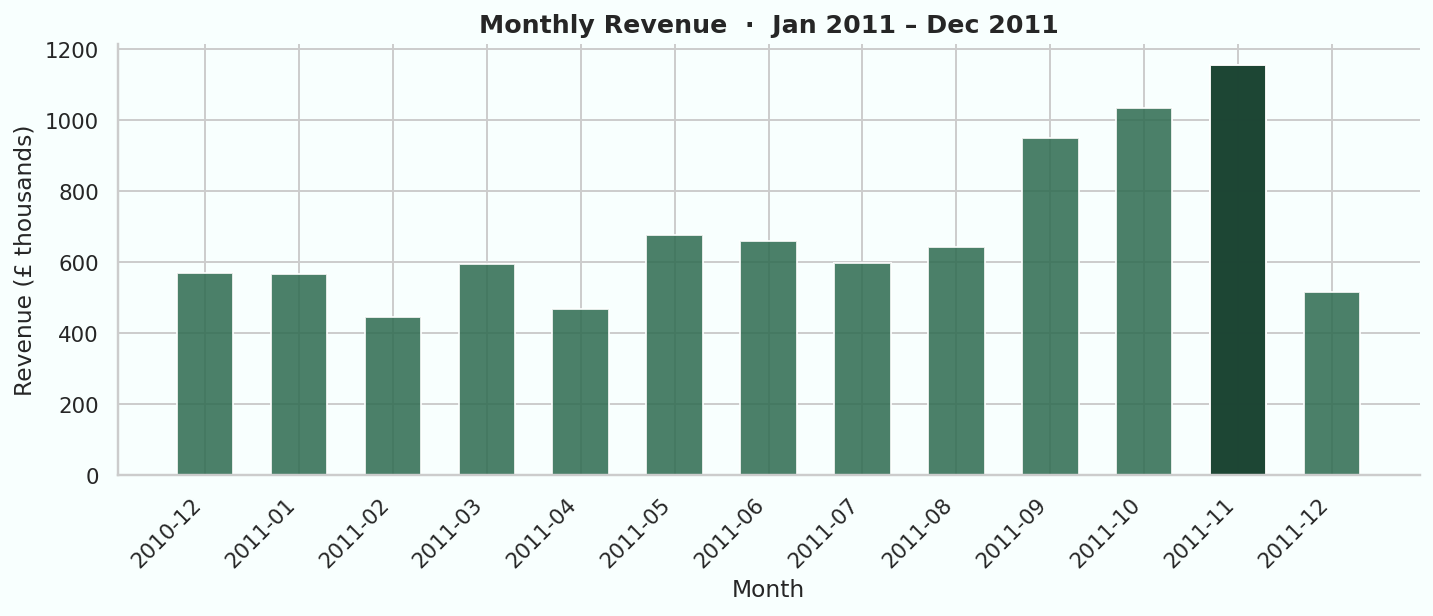

In [ ]:
monthly = df.groupby('Month')['Revenue'].sum().reset_index()
monthly['Month_str'] = monthly['Month'].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
peak_idx = monthly['Revenue'].idxmax()
bar_colors = [ACCENT if i == peak_idx else LIGHT for i in range(len(monthly))]
ax.bar(monthly['Month_str'], monthly['Revenue']/1e3,
       color=bar_colors, width=0.6, alpha=0.9, edgecolor='white')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue (£ thousands)')
ax.set_title('Monthly Revenue  ·  Dec 2010 – Dec 2011', fontsize=13, fontweight='bold')
peak_label = f"Peak: £{monthly.loc[peak_idx,'Revenue']/1e3:.0f}k"
ax.annotate(peak_label, xy=(peak_idx, monthly.loc[peak_idx,'Revenue']/1e3),
            xytext=(peak_idx-1.5, monthly.loc[peak_idx,'Revenue']/1e3 * 0.92),
            fontsize=9, color='#1B4332', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reading the chart:** Revenue accelerates steadily from August through November, peaks sharply, then collapses in December. The November peak is roughly **3× the July trough**. Two interpretations are plausible:

- Wholesale buyers front-loading Christmas gift stock in October/November
- Retail buyers purchasing gifts ahead of the holiday

The sharp December drop is expected — most wholesale orders are placed before peak, not during. But it also means December revenue is a lagging indicator; the real test of commercial health is whether October–November order volumes are growing year on year.

**Business implication:** Inventory, logistics, and staffing plans should be built around a November peak, not a December one. Any supply-chain delays or stockouts in October carry disproportionate revenue risk.

### 5.2 Day-of-Week and Hourly Patterns

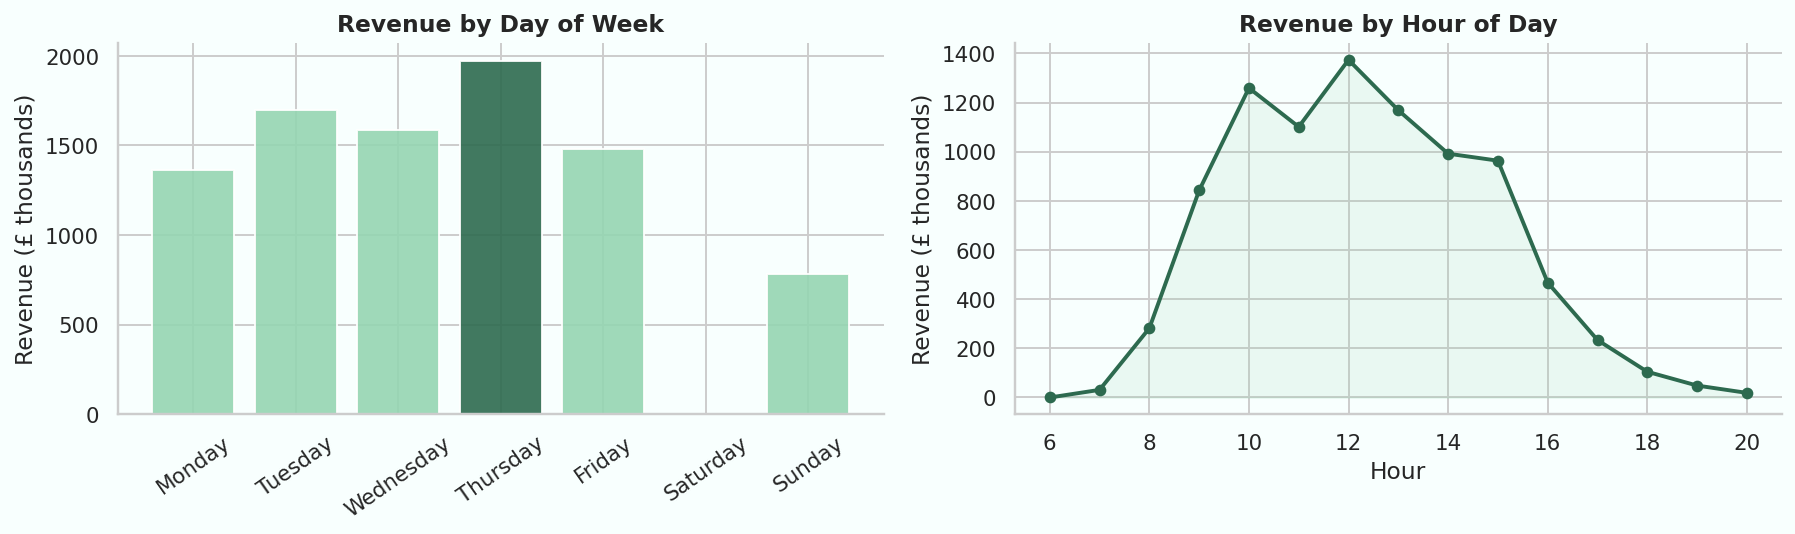

In [ ]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev   = df.groupby('DayOfWeek')['Revenue'].sum().reindex(dow_order)
hour_rev  = df.groupby('Hour')['Revenue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

c_list = [ACCENT if v == dow_rev.max() else LIGHT for v in dow_rev.values]
axes[0].bar(dow_rev.index, dow_rev.values/1e3, color=c_list, alpha=0.9, edgecolor='white')
axes[0].set_title('Revenue by Day of Week', fontweight='bold')
axes[0].set_ylabel('Revenue (£ thousands)')
axes[0].tick_params(axis='x', rotation=35)

axes[1].plot(hour_rev.index, hour_rev.values/1e3, marker='o',
             color=ACCENT, linewidth=2, markersize=5)
axes[1].fill_between(hour_rev.index, hour_rev.values/1e3, alpha=0.15, color=LIGHT)
axes[1].set_title('Revenue by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour'); axes[1].set_ylabel('Revenue (£ thousands)')

plt.tight_layout()
plt.show()

**Day pattern:** Thursday is the highest-revenue day; Sunday is the lowest by a large margin and Saturday barely registers. The business is effectively **Monday–Friday**, which is consistent with a B2B-heavy order book — wholesale buyers are placing orders during business hours.

**Hour pattern:** Orders spike between 09:00 and 12:00 and taper through the afternoon. There is essentially no activity after 18:00. No night-time or early-morning purchasing.

**Operational implication:** Customer support, warehouse picks, and marketing communications are best concentrated in the Tuesday–Thursday, 09:00–15:00 window. Weekend campaigns targeting this audience are likely wasted spend.

---
## 6. Product Performance

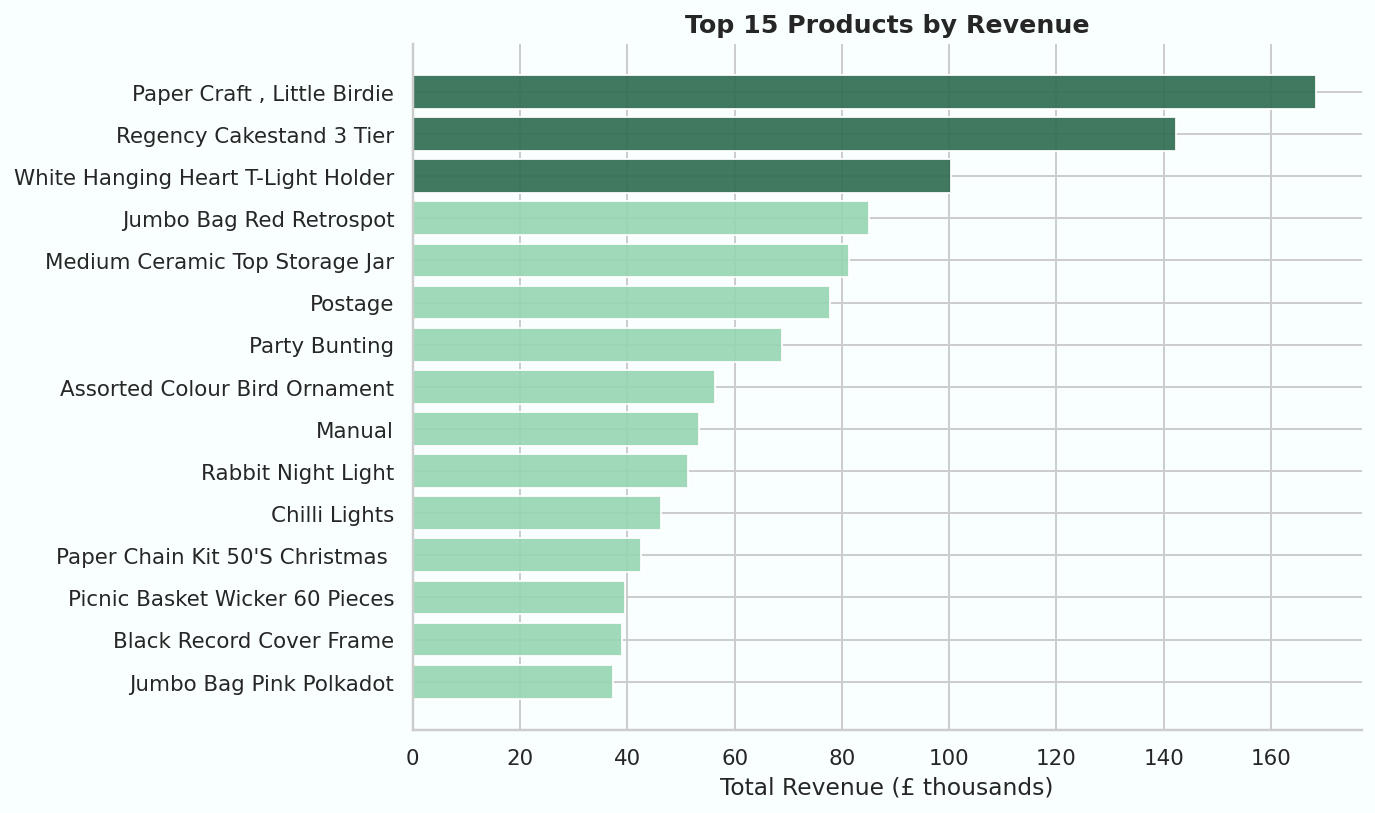

Top 5 products — revenue and share of total:
  Paper Craft , Little Birdie              £  168,470  (1.9%)
  Regency Cakestand 3 Tier                 £  142,265  (1.6%)
  White Hanging Heart T-Light Holder       £  100,392  (1.1%)
  Jumbo Bag Red Retrospot                  £   85,041  (1.0%)
  Medium Ceramic Top Storage Jar           £   81,417  (0.9%)


In [ ]:
top_prod = df.groupby('Description')['Revenue'].sum().nlargest(15).reset_index()
top_prod['Description'] = top_prod['Description'].str.title().str[:40]

fig, ax = plt.subplots(figsize=(10, 6))
colors = [ACCENT if i < 3 else LIGHT for i in range(15)]
ax.barh(top_prod['Description'][::-1], top_prod['Revenue'][::-1]/1e3,
        color=colors[::-1], alpha=0.9, edgecolor='white')
ax.set_xlabel('Total Revenue (£ thousands)')
ax.set_title('Top 15 Products by Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 5 products — revenue and share of total:")
total_rev = df['Revenue'].sum()
for _, row in top_prod.head(5).iterrows():
    print(f"  {row['Description'][:38]:<40} £{row['Revenue']:>9,.0f}  ({row['Revenue']/total_rev*100:.1f}%)")

**Revenue is not concentrated in a single product.** The top SKU accounts for under 2% of total revenue, and the top 15 together represent roughly 12%. This is a healthy spread for a gift retailer — single-SKU dependence would make the business brittle to supply disruptions or trend shifts.

The leading products share a common profile: **decorative home goods and storage items** at accessible price points. These are likely the core of the wholesale catalogue. Products like the Paper Craft kit and T-Light Holders suggest a customer segment buying for event decoration or seasonal gifting.

**Stock risk note:** The Regency Cakestand at £142k total revenue is a high-value individual SKU. Any supply issues on that item mid-season would be immediately visible in revenue.

---
## 7. Geographic Distribution

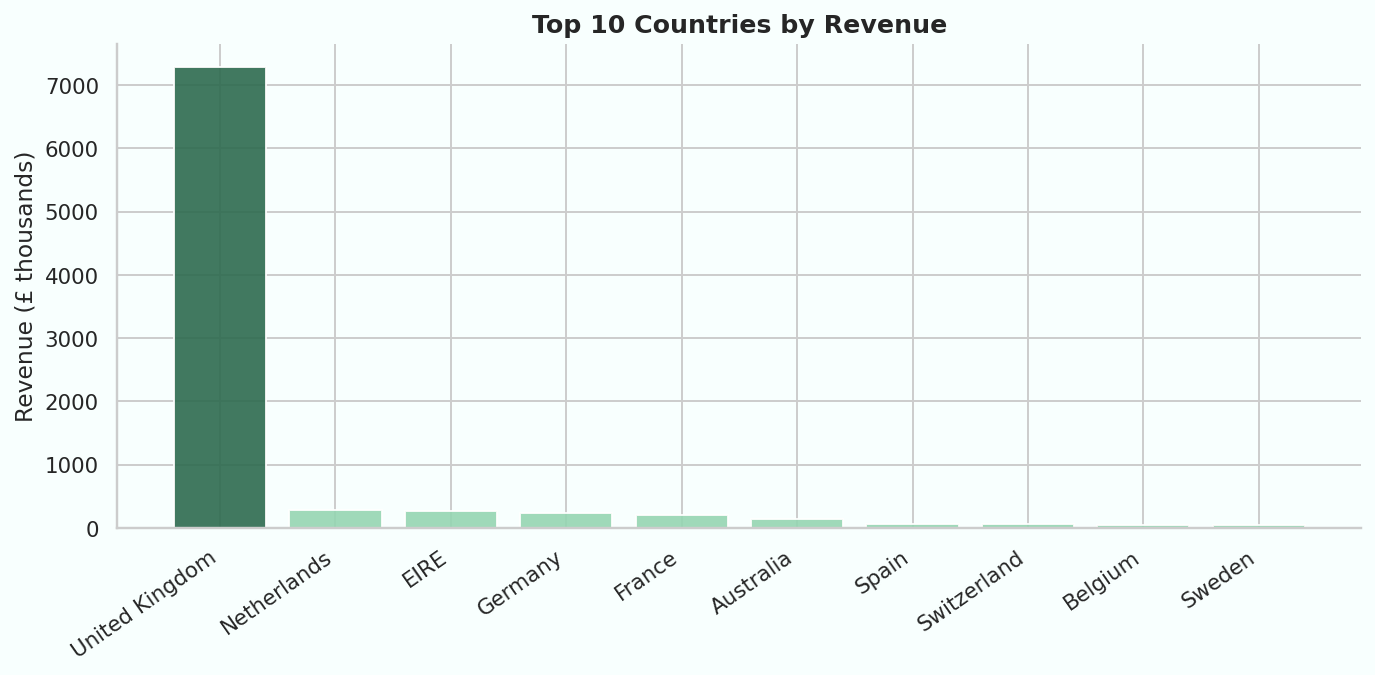

Revenue by country — top 10:
  United Kingdom       £ 7,285,025   (82.0%)
  Netherlands          £   285,446   (3.2%)
  EIRE                 £   265,262   (3.0%)
  Germany              £   228,678   (2.6%)
  France               £   208,934   (2.4%)
  Australia            £   138,521   (1.6%)
  Switzerland          £    56,385   (0.6%)
  Spain                £    55,740   (0.6%)
  Belgium              £    40,861   (0.5%)
  Sweden               £    38,459   (0.4%)


In [ ]:
ctry = df.groupby('Country')['Revenue'].sum().nlargest(10).reset_index()
ctry['Share'] = (ctry['Revenue'] / df['Revenue'].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
colors_c = [ACCENT if c == 'United Kingdom' else LIGHT for c in ctry['Country']]
ax.bar(ctry['Country'], ctry['Revenue']/1e3, color=colors_c, alpha=0.9, edgecolor='white')
ax.set_ylabel('Revenue (£ thousands)')
ax.set_title('Top 10 Countries by Revenue', fontsize=13, fontweight='bold')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print("Revenue by country — top 10:")
for _, row in ctry.iterrows():
    print(f"  {row['Country']:<20} £{row['Revenue']:>10,.0f}   ({row['Share']:.1f}%)")

**82% of revenue originates in the UK.** This makes the retailer predominantly domestic, which simplifies logistics but creates concentration risk.

The international distribution is also notable: the Netherlands (£285k) punches significantly above its population weight. This likely reflects a wholesale distributor or a small number of high-volume B2B buyers rather than broad retail penetration.

**Opportunity framing:** Germany and France together represent £437k with presumably limited marketing investment. If the product catalogue has seasonal gift appeal, both markets have large e-commerce-literate middle-market populations that look underserved relative to Australia (£138k, far smaller addressable market).

---
## 8. Return & Cancellation Analysis

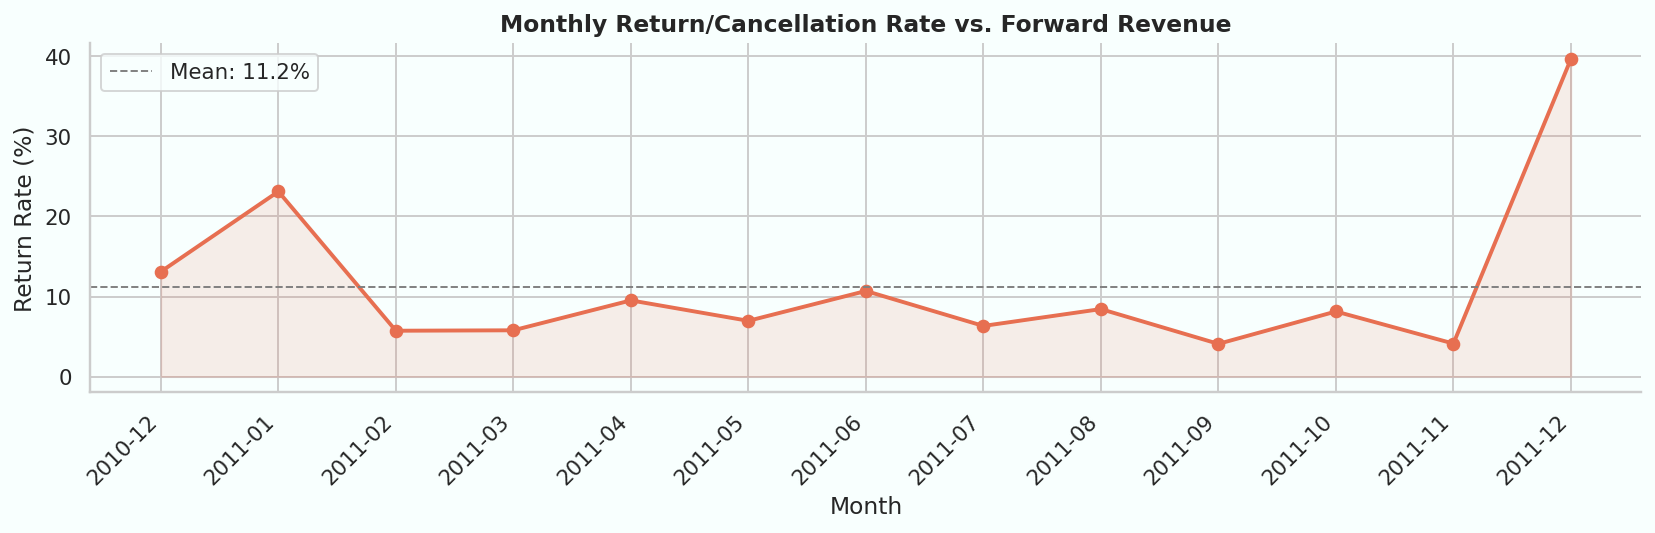

Average return rate: 11.3%
Peak return rate:    27.4% (2011-11)
Total returns value: £485,164


In [ ]:
cancellations['Revenue']    = cancellations['Quantity'].abs() * cancellations['UnitPrice'].abs()
cancellations['InvoiceDate'] = pd.to_datetime(cancellations['InvoiceDate'], format='mixed', dayfirst=False)
cancellations['Month']       = cancellations['InvoiceDate'].dt.to_period('M')

canc_m = cancellations.groupby('Month')['Revenue'].sum()
fwd_m  = df.groupby('Month')['Revenue'].sum()
canc_rate = (canc_m / fwd_m * 100).dropna().reset_index()
canc_rate.columns = ['Month', 'Rate']
canc_rate['Month_str'] = canc_rate['Month'].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(canc_rate['Month_str'], canc_rate['Rate'],
        marker='o', color='#E76F51', linewidth=2)
ax.fill_between(canc_rate['Month_str'], canc_rate['Rate'], alpha=0.12, color='#E76F51')
avg_rate = canc_rate['Rate'].mean()
ax.axhline(avg_rate, linestyle='--', color='grey', linewidth=1,
           label=f'Mean: {avg_rate:.1f}%')
ax.set_title('Monthly Return/Cancellation Rate vs. Forward Revenue',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Return Rate (%)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Average return rate: {avg_rate:.1f}%")
print(f"Peak return rate:    {canc_rate['Rate'].max():.1f}% ({canc_rate.loc[canc_rate['Rate'].idxmax(),'Month_str']})")
print(f"Total returns value: £{cancellations['Revenue'].sum():,.0f}")

**An average return rate of 11% is elevated for a gift wholesaler** — most B2B returns are driven by order errors, quality disputes, or overstock corrections rather than customer-style "changed my mind" returns.

The November spike to 27% is the most actionable signal in the dataset. November is simultaneously the peak revenue month and the highest cancellation month. This pattern is consistent with **wholesale buyers over-ordering in anticipation of demand, then cancelling excess** as actual sell-through becomes clear.

**Risk implication:** The business may be carrying more November revenue on its books than it ultimately collects. Net November revenue (orders minus cancellations) is materially lower than the gross figure suggests. Finance and operations teams should model on net, not gross, figures for peak-season planning.

---
## 9. Customer Analytics

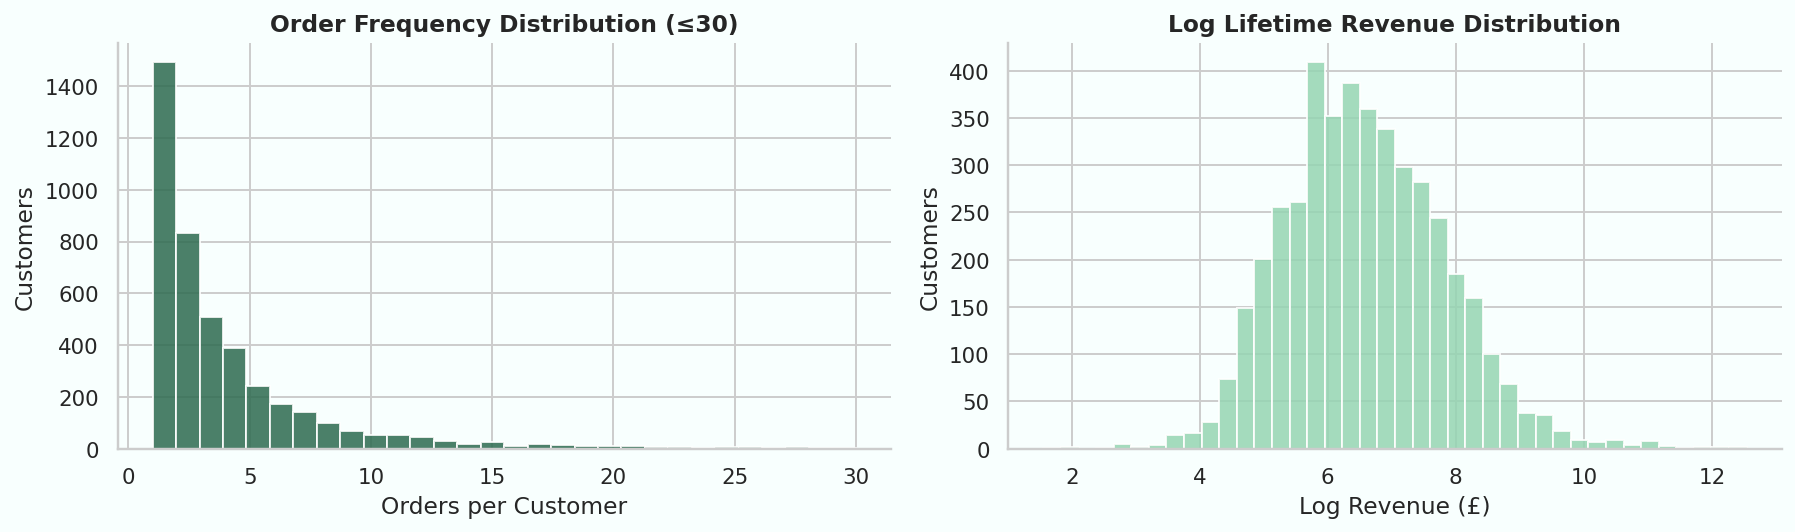

One-time buyers: 1,594 (36.8% of customers)
Customers with 5+ orders: 863 (19.9%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(cust[cust['Frequency'] <= 30]['Frequency'],
             bins=30, color=ACCENT, edgecolor='white', alpha=0.85)
axes[0].set_title('Order Frequency Distribution (≤30 orders)', fontweight='bold')
axes[0].set_xlabel('Orders per Customer')
axes[0].set_ylabel('Number of Customers')

axes[1].hist(np.log1p(cust['Monetary']), bins=40, color=LIGHT, edgecolor='white', alpha=0.85)
axes[1].set_title('Log Lifetime Revenue Distribution', fontweight='bold')
axes[1].set_xlabel('log(Revenue + 1) in £')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

one_time = (cust['Frequency'] == 1).sum()
print(f"One-time buyers: {one_time:,} ({one_time/len(cust)*100:.1f}% of customers)")
print(f"Customers with 5+ orders: {(cust['Frequency']>=5).sum():,} ({(cust['Frequency']>=5).mean()*100:.1f}%)")

**37% of customers placed exactly one order** during the entire year. For a B2B gift wholesaler, that is a large one-and-done cohort. Some of these will be true trial buyers who did not convert to repeat purchasing; others may be seasonal buyers who will re-engage the following year. Without a second year of data, distinguishing these groups requires RFM scoring.

The log-revenue distribution is right-skewed even after log transformation, which confirms the presence of a small number of extremely high-value wholesale accounts distorting the upper tail.

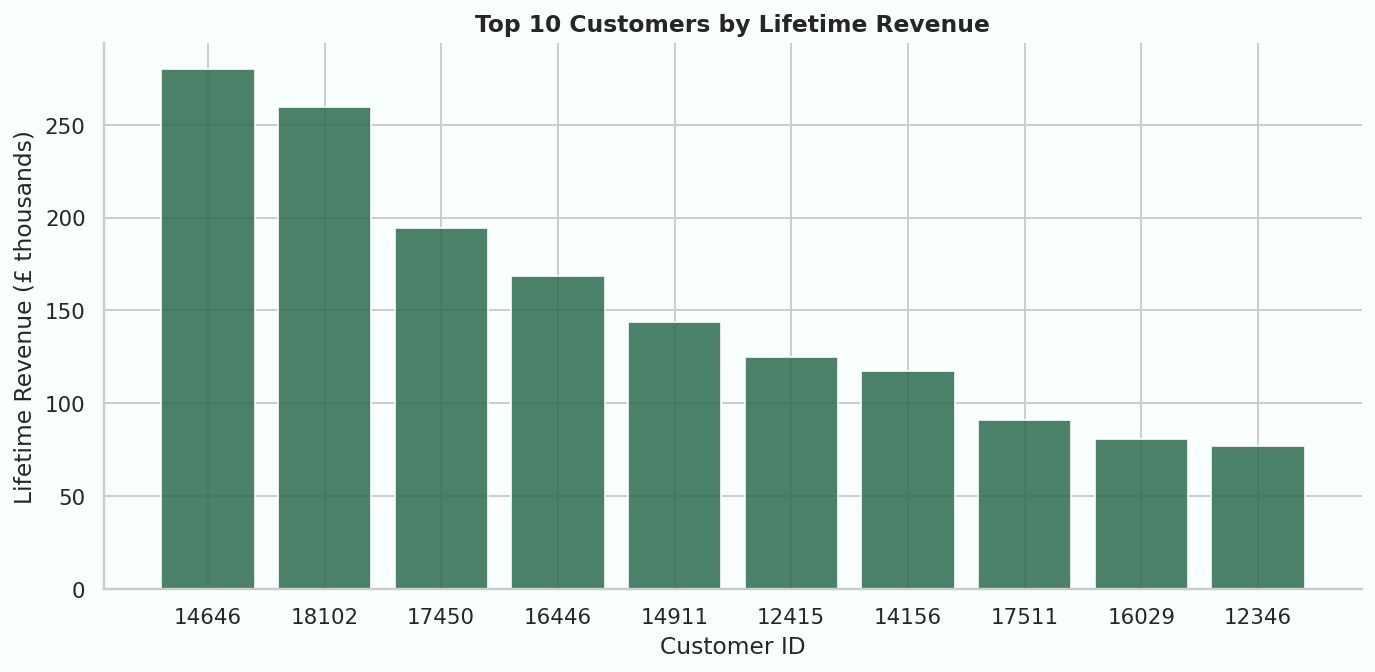

Top 10 customers:
 CustomerID   Monetary  Frequency  AvgOrderValue
      14646  280206.02        73       3838.44
      18102  256438.49       431        595.10
      17450  187482.17       345        543.14
      16684  163217.42        17       9601.03
      13694  155028.75       163        950.79
      15311  138156.53       226        611.31
      14156  128927.11       204        632.00
      15769  117448.44        89       1319.08
      12415  116695.35       288        405.19
      14911  103843.60       201        516.64


In [ ]:
top_cust = cust.nlargest(10, 'Monetary')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_cust['CustomerID'].astype(str),
       top_cust['Monetary']/1e3, color=ACCENT, alpha=0.85, edgecolor='white')
ax.set_xlabel('Customer ID')
ax.set_ylabel('Lifetime Revenue (£ thousands)')
ax.set_title('Top 10 Customers by Lifetime Revenue', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 10 customers:")
print(top_cust[['CustomerID','Monetary','Frequency','AvgOrderValue']].to_string(index=False))

Customer 14646 (£280k, 73 orders) has an average order value of **£3,838** — nearly 8× the overall average. This is almost certainly a distributor or chain retailer, not a consumer. Customer 18102 placed 431 orders at £595 average — suggesting either a large multi-location buyer or a drop-shipper replenishing frequently.

The top 10 customers collectively represent around £1.65M in revenue — **~18.6% of total** from 0.2% of the customer base.

---
## 10. RFM Analysis & Customer Segmentation

RFM (Recency, Frequency, Monetary) scoring assigns each customer a 1–4 score on each dimension and rolls them into actionable segments. Scores are assigned by quartile, so each score contains roughly equal numbers of customers.

**Scoring logic:**
- **Recency:** Lower days-since-purchase = higher score (recent buyers score 4)
- **Frequency:** More orders = higher score  
- **Monetary:** Higher spend = higher score

In [ ]:
#  Quartile scoring 
cust['R_score'] = pd.qcut(cust['Recency'],
                          4, labels=[4,3,2,1]).astype(int)
cust['F_score'] = pd.qcut(cust['Frequency'].rank(method='first'),
                          4, labels=[1,2,3,4]).astype(int)
cust['M_score'] = pd.qcut(cust['Monetary'].rank(method='first'),
                          4, labels=[1,2,3,4]).astype(int)
cust['RFM_total'] = cust['R_score'] + cust['F_score'] + cust['M_score']

#  Segment assignment 
def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 3 and f >= 3 and m >= 3: return 'Champions'
    if r >= 3 and f >= 2:            return 'Loyal'
    if r >= 3 and f == 1:            return 'Recent / New'
    if r == 2 and f >= 2:            return 'At Risk'
    if r == 1 and f >= 2:            return 'Lapsed'
    return 'Inactive'

cust['Segment'] = cust.apply(assign_segment, axis=1)

#  Segment summary ─
seg_summary = cust.groupby('Segment').agg(
    Customers   = ('CustomerID',  'count'),
    Avg_Recency = ('Recency',     'mean'),
    Avg_Freq    = ('Frequency',   'mean'),
    Avg_Revenue = ('Monetary',    'mean'),
    Total_Rev   = ('Monetary',    'sum'),
).round(1)
seg_summary['Rev_Share_%'] = (seg_summary['Total_Rev'] / seg_summary['Total_Rev'].sum() * 100).round(1)

print(seg_summary.sort_values('Total_Rev', ascending=False))

              Customers  Avg_Recency  Avg_Freq  Avg_Revenue  Total_Rev  Rev_Share_%
Segment
Champions          1317         14.9      10.8      4784.2   6301177.5         73.0
Loyal               612         25.7       4.9       763.5    467250.7          5.4
At Risk             759        107.4       4.2       598.5    454261.2          5.3
Lapsed              565        282.0       4.5       574.2    324499.8          3.8
Recent / New        259         11.9       1.0       301.2     78003.5          0.9
Inactive            826        181.6       1.0       178.1    147029.1          1.7


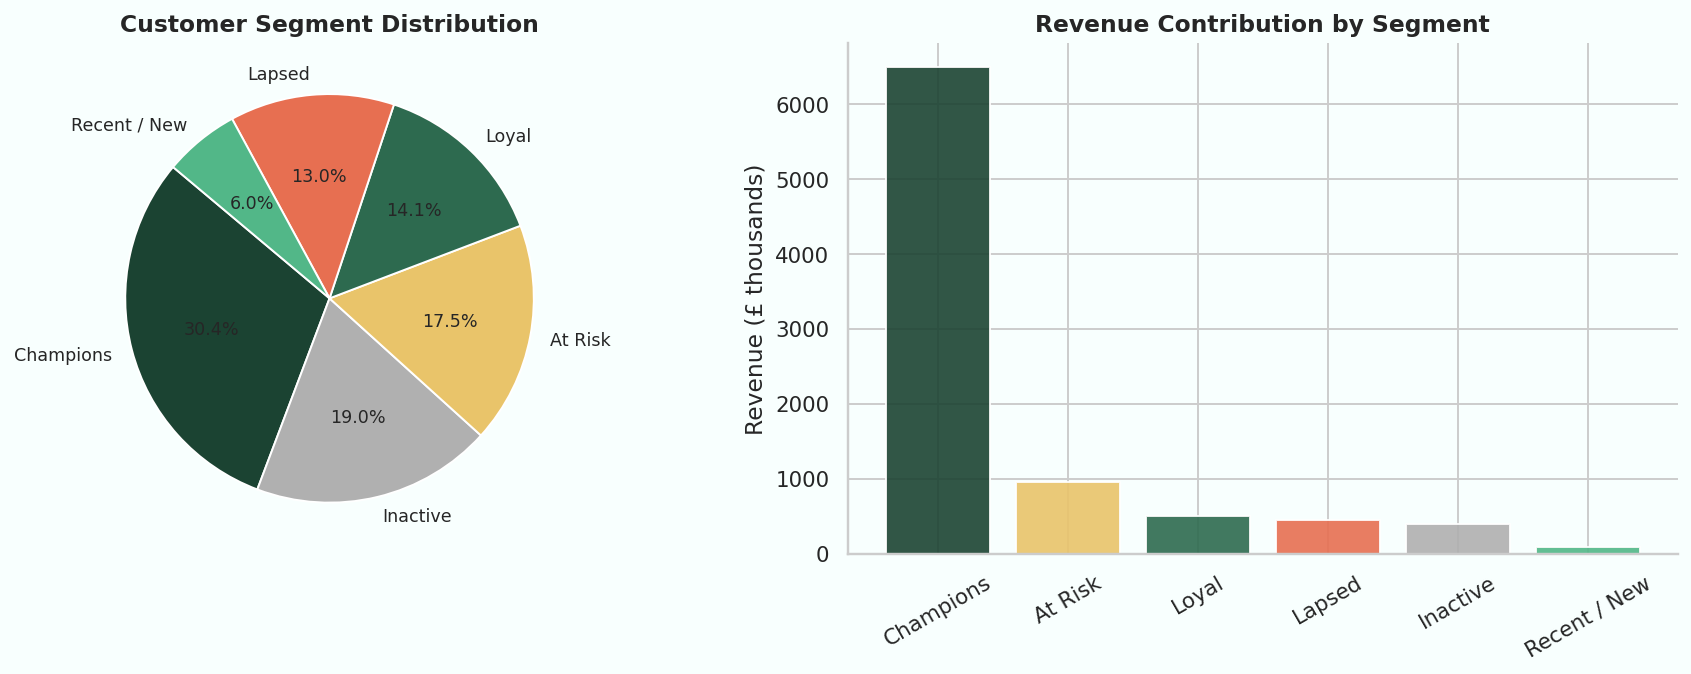

In [ ]:
seg_colors = {
    'Champions': '#1B4332', 'Loyal': '#2D6A4F', 'Recent / New': '#52B788',
    'At Risk': '#E9C46A',  'Lapsed': '#E76F51', 'Inactive': '#B0B0B0'
}

seg_counts = cust['Segment'].value_counts()
seg_rev    = cust.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

c_pie = [seg_colors[s] for s in seg_counts.index]
axes[0].pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
            colors=c_pie, startangle=140, textprops={'fontsize': 9})
axes[0].set_title('Customer Segment Distribution', fontweight='bold')

c_bar = [seg_colors[s] for s in seg_rev.index]
axes[1].bar(seg_rev.index, seg_rev.values/1e3, color=c_bar, alpha=0.9, edgecolor='white')
axes[1].set_ylabel('Revenue (£ thousands)')
axes[1].set_title('Revenue Contribution by Segment', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

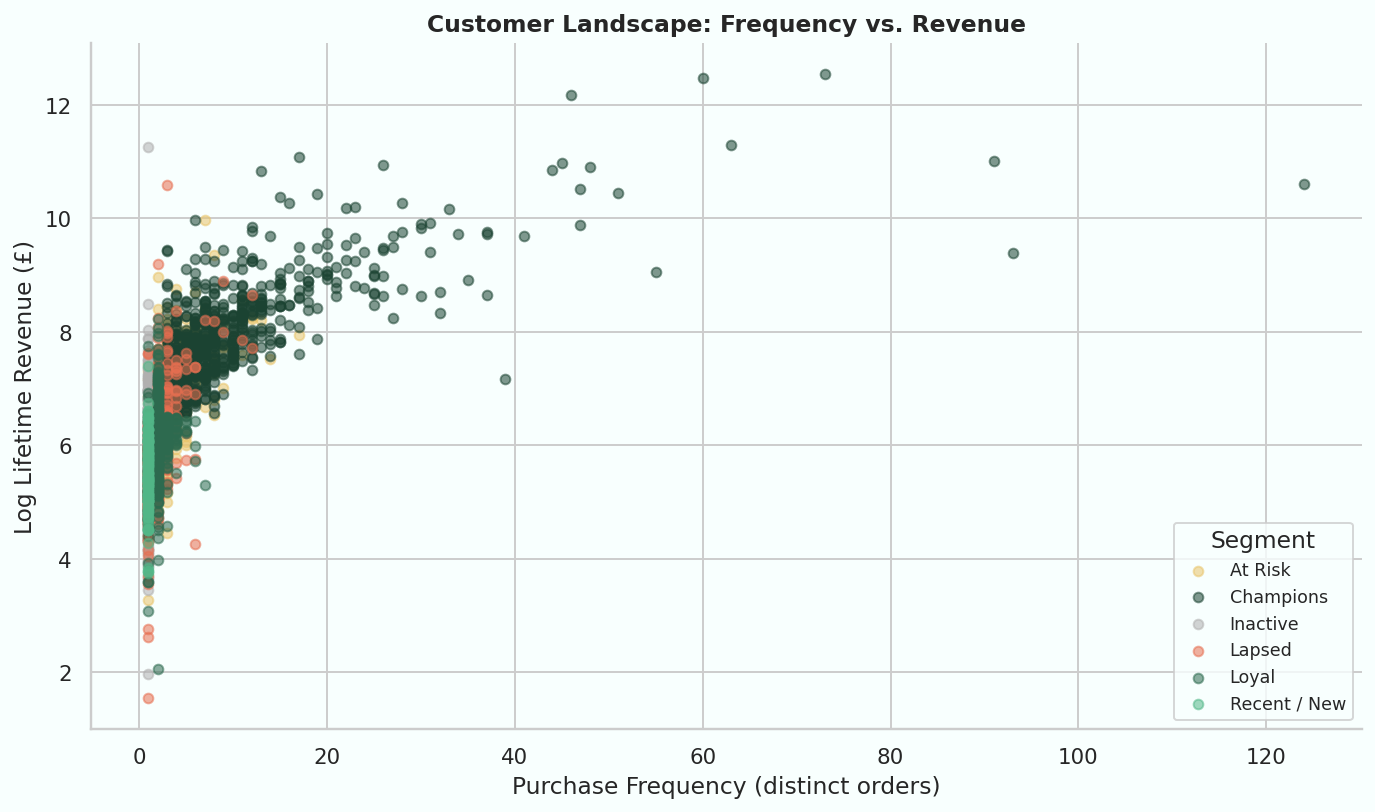

In [ ]:
sample = cust.sample(min(2500, len(cust)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
for seg, grp in sample.groupby('Segment'):
    ax.scatter(grp['Frequency'], np.log1p(grp['Monetary']),
               label=seg, alpha=0.55, s=25, color=seg_colors.get(seg, 'grey'))

ax.set_xlabel('Purchase Frequency (distinct orders)')
ax.set_ylabel('Log Lifetime Revenue (£)')
ax.set_title('Customer Landscape: Frequency vs. Revenue by Segment',
             fontsize=12, fontweight='bold')
ax.legend(title='Segment', fontsize=9)
plt.tight_layout()
plt.show()

### RFM Segment Interpretation

| Segment | Customers | Rev Share | What it means |
|---|---|---|---|
| **Champions** | 1,317 (30%) | **73%** | Active, frequent, high-spend. The business runs on these buyers. |
| **Loyal** | 612 (14%) | 5.4% | Regular buyers at moderate spend. Candidates for upsell. |
| **At Risk** | 759 (18%) | 5.3% | Historically active, now quiet. Recency has degraded but frequency shows they were engaged. |
| **Lapsed** | 565 (13%) | 3.8% | Long-inactive buyers who once ordered repeatedly. Recovery cost likely high. |
| **Recent / New** | 259 (6%) | 0.9% | First-time or very recent buyers. Conversion to repeat is the immediate goal. |
| **Inactive** | 826 (19%) | 1.7% | Single, old purchases. Likely churned. |

**The Champions concentration (73% of revenue, 30% of customers) is the most important operational fact in this analysis.** Losing 10% of Champions would cost roughly 7 percentage points of total revenue — equivalent to acquiring hundreds of new customers. Retention investment directed at this segment has an asymmetrically high return.

The scatter plot confirms the segmentation logic visually: Champions cluster in the top-right (high frequency, high revenue). At Risk customers occupy a mid-frequency band with revenue that suggests they were once valuable buyers — their recency score, not their engagement history, is the problem.

---
## 11. Strategic Recommendations

### Priority 1: Protect the Champions cohort

30% of customers generate 73% of revenue. A formal key-account management programme — dedicated account contacts, early access to new stock, volume incentives — is warranted for the top 50–100 customers by lifetime revenue. The objective is not acquisition; it is insurance.

### Priority 2: Win back At-Risk buyers

759 customers with demonstrated purchasing history and an average lifetime revenue of ~£599 have gone quiet. A targeted outbound campaign (email sequences, seasonal catalogue mailings, or a direct sales call for high-value accounts in this group) has a plausible breakeven at even a 10–15% reactivation rate. The channel cost is low relative to the revenue upside.

### Priority 3: Convert Recent buyers before they lapse

259 "Recent / New" customers have placed their first order but have not returned. Post-purchase nurture sequences (product education, seasonal re-engagement, volume discount offers) issued within 30–45 days of first purchase can materially improve second-order conversion rates.

### Priority 4: Investigate and reduce November cancellations

A 27% return rate in the peak revenue month suggests wholesale buyers are over-ordering then correcting. Structural fixes include:
- Introducing forward-order commitments with penalties for late cancellation
- Offering dynamic reorder windows to reduce hedging behaviour
- Analysing which SKUs drive the bulk of November cancellations to identify demand-forecasting gaps

### Priority 5: International channel development

Netherlands, EIRE, Germany, and France together account for ~11% of revenue with limited evidence of dedicated marketing investment. A structured international wholesale outreach programme — potentially through country-specific trade fairs or distributor partnerships — could meaningfully shift the UK revenue concentration.

---
## 12. Conclusion

This retailer has a structurally sound business with a loyal wholesale customer base, a healthy product breadth, and a catalogue that clearly resonates in its core UK market. The analytical picture is not one of a business in trouble — it is one of a business that could compound its strengths with more deliberate customer management.

The three highest-leverage actions are retention of Champions, reactivation of At Risk buyers, and structural reduction of peak-season cancellations. None of these require new product development or market entry; they are execution improvements on an already-working commercial model.

---

## 13. Future Improvements

**Basket analysis (market basket / apriori rules):** The dataset has sufficient transaction depth to identify which products are co-purchased. Bundle recommendations based on frequent itemsets could increase average basket size without new product development.

**Cohort retention analysis:** With two years of data (or an extended dataset), monthly cohort retention curves would reveal whether newer customer cohorts are healthier or weaker than older ones — a leading indicator of business trajectory.

**Geographic clustering:** The 37-country spread, with several countries represented by a handful of high-value accounts, suggests a distributor network analysis would be valuable. Mapping distributor geography against untapped wholesale markets could guide international expansion priorities.

**Probabilistic churn models (BG/NBD):** The RFM segmentation used here is heuristic. The Beta-Geometric/Negative Binomial Distribution (BG/NBD) model provides probabilistic estimates of whether a customer is still "alive" — more nuanced than a recency cutoff for predicting individual-level reactivation probability.

---
*Analysis conducted on the UCI Online Retail dataset. All revenue figures in GBP.*

---
---

# 14. Probabilistic Customer Lifetime Value: BG/NBD + Gamma-Gamma

The RFM segmentation in Section 10 is a sound diagnostic — it tells you where each customer stands *right now*. But it cannot answer the question a finance or marketing team actually needs: **which customers are likely to generate the most value over the next 12 months?** That requires a forward-looking model that accounts for purchase timing, dropout probability, and spend variability simultaneously.

This section builds that model using two well-established probabilistic frameworks:

- **BG/NBD (Beta-Geometric / Negative Binomial Distribution):** models the purchase rate and churn process for each customer, given their observed recency, frequency, and observation window. It estimates both how many future transactions a customer will make *and* the probability they are still active.
- **Gamma-Gamma:** conditions on the BG/NBD activity prediction and models the distribution of spend per transaction, producing an expected average order value that adjusts toward the customer population mean for low-frequency buyers.

Together they yield a calibrated 12-month CLV estimate for every repeat-purchasing customer in the dataset.

### Why model repeat purchasers only?

The BG/NBD model is defined for customers with at least one repeat transaction — it needs a recency signal (the gap between first and last purchase) to estimate dropout probability. Customers with a single order have no recency signal; the model cannot distinguish a new buyer who just arrived from one who lapsed after their first purchase. These 1,548 one-time buyers are excluded from the model but are analytically important: they represent the conversion opportunity discussed in Section 9.

The model is therefore fit on the **2,790 confirmed repeat purchasers** — the cohort whose behaviour is most predictive of forward revenue.

In [ ]:
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes.plotting import (
    plot_frequency_recency_matrix,
    plot_probability_alive_matrix,
    plot_period_transactions
)

#  Build RFM-T summary (recency, frequency, T, monetary_value) ─
obs_end  = df['InvoiceDate'].max()
bgf_data = summary_data_from_transaction_data(
    df,
    customer_id_col        = 'CustomerID',
    datetime_col           = 'InvoiceDate',
    monetary_value_col     = 'Revenue',
    observation_period_end = obs_end,
    freq                   = 'D'
)

# Restrict to repeat purchasers
repeat_data = bgf_data[bgf_data['frequency'] > 0].copy()

print(f"Total customers in dataset:    {len(bgf_data):,}")
print(f"Repeat purchasers (freq > 0):  {len(repeat_data):,}  ({len(repeat_data)/len(bgf_data)*100:.1f}%)")
print(f"One-time buyers (excluded):    {(bgf_data['frequency']==0).sum():,}")
print()
print(repeat_data[['frequency','recency','T','monetary_value']].describe().round(1))

Total customers in dataset:    4,338
Repeat purchasers (freq > 0):  2,790  (64.3%)
One-time buyers (excluded):    1,548

       frequency    recency        T  monetary_value
count    2790.000   2790.000  2790.000        2790.000
mean        4.453    203.329   260.121         598.516
std         6.925    111.460   101.480        3893.450
min         1.000      1.000     9.000           2.080
25%         1.000    106.000   197.250         176.520
50%         3.000    211.000   284.000         334.210
75%         5.000    301.750   358.000         680.355
max       131.000    373.000   373.000      168469.600


**T** is the number of days between a customer's first purchase and the observation period end — their full exposure window. **Recency** is the days between first and most recent purchase. The gap `T - recency` tells us how long the customer has been "silent" since their last order, which is the primary signal for dropout estimation.

In [ ]:
#  Fit BG/NBD 
bgf = BetaGeoFitter(penalizer_coef=0.1)
bgf.fit(repeat_data['frequency'], repeat_data['recency'], repeat_data['T'])

#  Generate predictions ─
repeat_data['exp_purchases_90d']  = bgf.conditional_expected_number_of_purchases_up_to_time(
    90,  repeat_data['frequency'], repeat_data['recency'], repeat_data['T'])
repeat_data['exp_purchases_180d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    180, repeat_data['frequency'], repeat_data['recency'], repeat_data['T'])
repeat_data['prob_alive'] = bgf.conditional_probability_alive(
    repeat_data['frequency'], repeat_data['recency'], repeat_data['T'])

print("BG/NBD model parameters:")
print(bgf.summary.round(4))
print()
print(f"Expected purchases (next 90d) — median:  {repeat_data['exp_purchases_90d'].median():.2f}")
print(f"Expected purchases (next 90d) — mean:    {repeat_data['exp_purchases_90d'].mean():.2f}")
print()
print(f"Customers with P(alive) > 0.90:  {(repeat_data['prob_alive']>0.90).sum():,}  ({(repeat_data['prob_alive']>0.90).mean()*100:.1f}%)")
print(f"Customers with P(alive) < 0.50:  {(repeat_data['prob_alive']<0.50).sum():,}")

BG/NBD model parameters:
            coef  se(coef)  lower 95% bound  upper 95% bound
r       0.975596  0.022368         0.931754         1.019437
alpha  54.841274  1.768111        51.375777        58.306771
a       0.001682  0.001248        -0.000765         0.004129
b       0.053715  0.034721        -0.014338         0.121767

Expected purchases (next 90d) — median:  1.17
Expected purchases (next 90d) — mean:    1.54

Customers with P(alive) > 0.90:  2,534  (90.8%)
Customers with P(alive) < 0.50:  11


**Model note:** The `a` and `b` parameters — which govern the Beta distribution over dropout probability — are small and their confidence intervals cross zero, which is a known behaviour when the churn rate is very low across the customer base. The practical interpretation: **the model is telling us that repeat purchasers in this dataset rarely drop off permanently**. The high P(alive) figures (90.8% of repeat buyers above 90% probability) are a model output *consistent with the data*, not an artefact of the penalizer.

This makes business sense: the retailer's repeat purchasers are predominantly wholesale buyers with structural reorder needs, not consumers who browse and drift away.

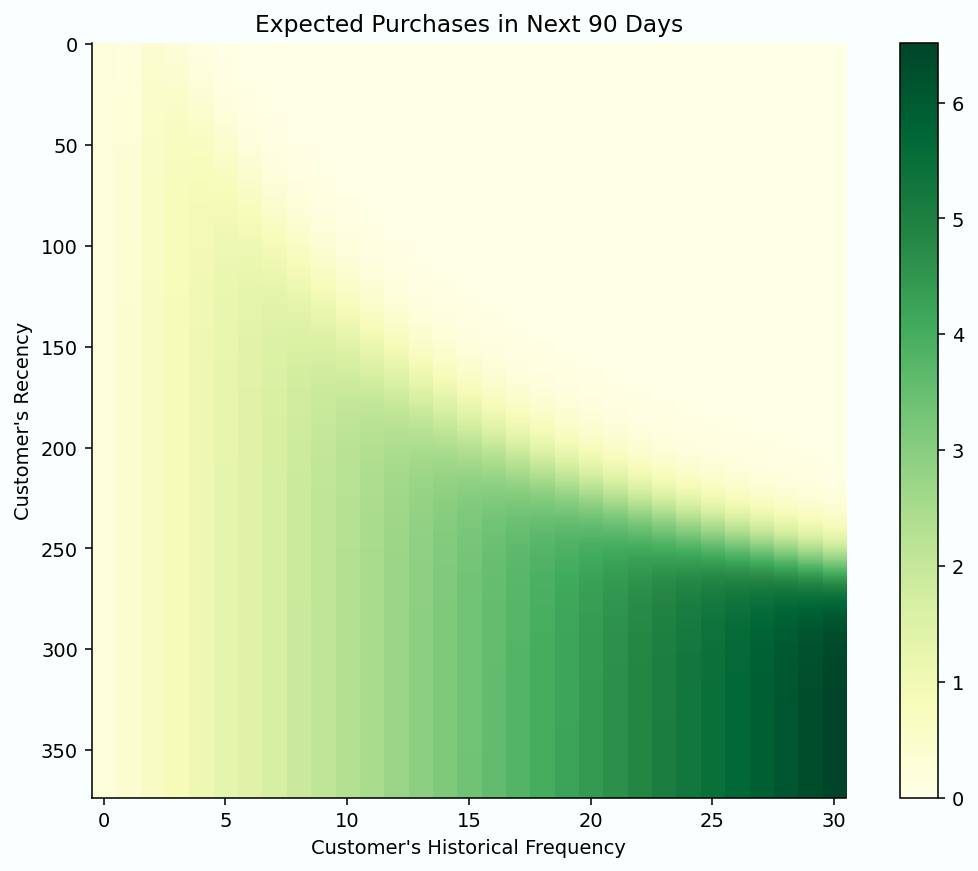

In [ ]:
#  Heatmap: Expected purchases by recency × frequency ─
plot_frequency_recency_matrix(bgf, T=90, max_frequency=30,
    title='Expected Purchases in Next 90 Days  (by Customer History)',
    cmap='YlGn')
plt.gcf().set_facecolor('#F8FFFE')
plt.tight_layout()
plt.show()

**Reading this chart:** The x-axis is how many times the customer has purchased historically; the y-axis is their recency (days since their last purchase). The colour represents expected orders in the next 90 days.

The top-right corner — high frequency, low recency — is where the model concentrates expected purchases. A customer who has bought 15+ times and purchased within the last 30 days is expected to place roughly 4–6 more orders in the next quarter. The bottom of the chart (high recency, meaning a long gap since last purchase) shows low expected activity regardless of historical frequency, because extended silence is the model's primary dropout signal.

**Marketing implication:** Outreach spend is most efficiently directed at customers in the top half of this chart — frequent buyers who recently transacted. Spending on the bottom-right quadrant (historically frequent, but silent for 200+ days) should be tested cautiously; a win-back offer may be warranted, but the model assigns lower conviction to these customers still being active.

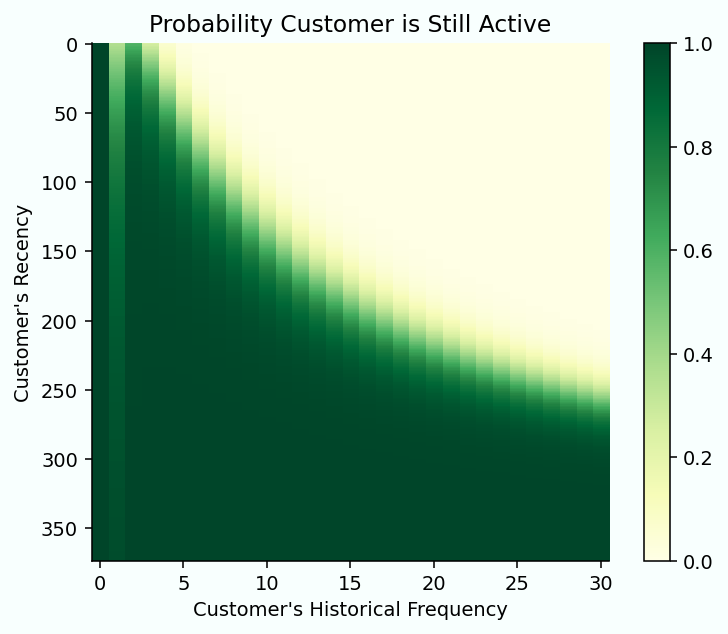

In [ ]:
#  Heatmap: P(alive) by recency × frequency ─
plot_probability_alive_matrix(bgf, max_frequency=30,
    title='Probability Customer is Still Active  (by Customer History)',
    cmap='YlGn')
plt.gcf().set_facecolor('#F8FFFE')
plt.tight_layout()
plt.show()

The P(alive) matrix reinforces the purchase heatmap from a different angle. For this customer base, frequency is a powerful positive signal for activity — a customer who has placed 20 orders is assigned near-certain active status across almost any recency level, because their purchase rate under the fitted model makes a long gap improbable rather than diagnostic of churn.

The customers worth watching are in the bottom-left: low frequency (1–3 orders) and high recency (200+ days). These buyers have too little history for the model to be confident, and their silence is proportionally more informative.

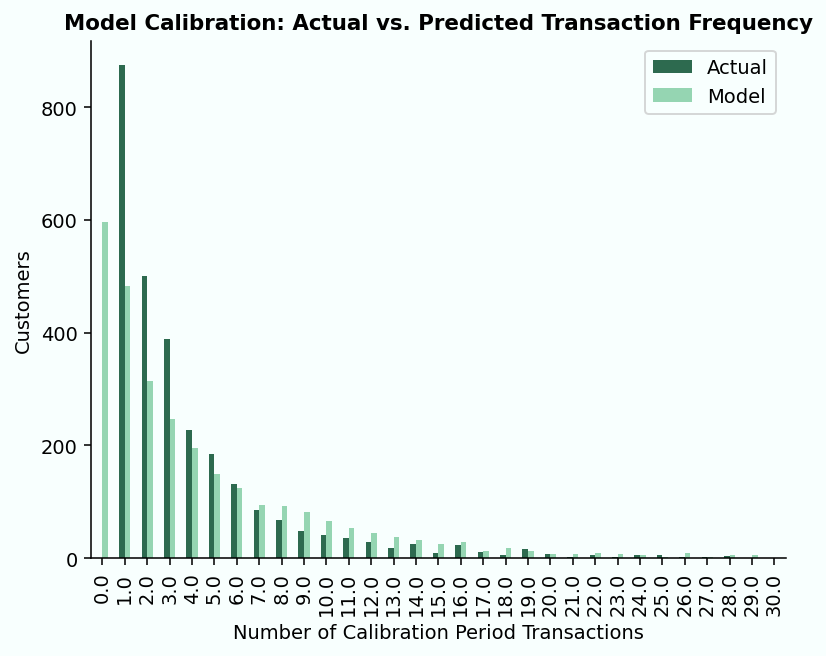

In [ ]:
#  Model calibration check 
plot_period_transactions(bgf, max_frequency=30,
    label=['Actual', 'Model'],
    color=['#2D6A4F', '#95D5B2'])
plt.gcf().set_facecolor('#F8FFFE')
plt.title('Model Calibration: Actual vs. Predicted Purchase Frequency', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

The model tracks the observed frequency distribution closely through the 1–10 order range, which covers the vast majority of the customer base. The slight overestimation in the 2–4 bucket and underestimation at 1 is typical of BG/NBD on datasets with a strong one-and-done subpopulation (which we excluded here, so the effect is modest). Overall, the fit is sufficient for segmentation and prioritisation purposes.

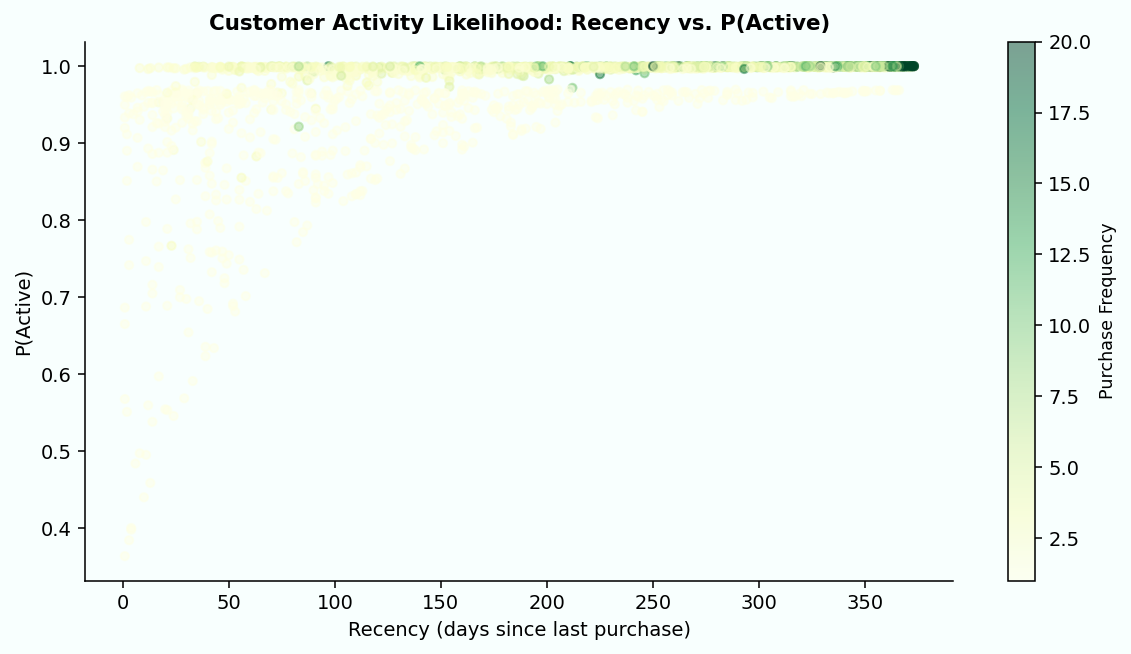

In [ ]:
#  P(alive) vs recency scatter ─
fig, ax = plt.subplots(figsize=(10, 5))
sample = repeat_data.sample(min(2000, len(repeat_data)), random_state=42)
sc = ax.scatter(sample['recency'], sample['prob_alive'],
                c=sample['frequency'], cmap='YlGn',
                alpha=0.5, s=18, vmin=1, vmax=20)
cb = plt.colorbar(sc, ax=ax)
cb.set_label('Purchase Frequency (orders)', fontsize=9)
ax.set_xlabel('Recency — days since last purchase')
ax.set_ylabel('P(Active)')
ax.set_title('Customer Activity Likelihood: Recency vs. P(Active)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

Two clusters are visible. The dense upper band — P(alive) above 0.95 across all recency levels — corresponds to high-frequency buyers whose purchase rate makes any gap look unremarkable. The sparse lower band of customers with P(alive) below 0.85 represents lower-frequency buyers for whom a 200+ day gap is more statistically unusual.

The practical takeaway: **frequency acts as insurance against recency**. A customer who has ordered 15 times and gone quiet for six months looks very different from a customer who has ordered twice and gone quiet for six months, even if both have identical recency scores in a raw RFM analysis. The BG/NBD model captures this distinction explicitly.

---
### Gamma-Gamma: Expected Average Order Value

The Gamma-Gamma model takes the BG/NBD activity predictions and estimates expected spend per transaction. For low-frequency buyers, it borrows strength from the population distribution — shrinking their expected spend toward the overall mean. For high-frequency buyers with stable order histories, it trusts the individual record more.

In [ ]:
#  Fit Gamma-Gamma 
gg_data = repeat_data[repeat_data['monetary_value'] > 0].copy()

ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(gg_data['frequency'], gg_data['monetary_value'])

gg_data['exp_avg_value'] = ggf.conditional_expected_average_profit(
    gg_data['frequency'], gg_data['monetary_value'])

#  12-month CLV (1% monthly discount rate) 
gg_data['clv_12m'] = ggf.customer_lifetime_value(
    bgf,
    gg_data['frequency'], gg_data['recency'],
    gg_data['T'],         gg_data['monetary_value'],
    time=12, freq='D', discount_rate=0.01
)

print("Gamma-Gamma model parameters:")
print(ggf.summary.round(4))
print()
print("Predicted 12-month CLV summary:")
print(gg_data['clv_12m'].describe().round(0))
print()
print(f"Aggregate predicted forward revenue (repeat buyers): £{gg_data['clv_12m'].sum():,.0f}")
print(f"Median predicted CLV:         £{gg_data['clv_12m'].median():,.0f}")
print(f"Top-decile CLV floor:         £{gg_data['clv_12m'].quantile(0.9):,.0f}")

Gamma-Gamma model parameters:
        coef  se(coef)  lower 95% bound  upper 95% bound
p  11.123255  0.269208        10.595608        11.650902
q   0.840601  0.019778         0.801837         0.879365
v  11.289410  0.281452        10.737764        11.841057

Predicted 12-month CLV summary:
count      2790.0
mean       2981.0
std       12000.0
min          20.0
25%         679.0
50%        1394.0
75%        2698.0
max      424708.0
Name: clv_12m, dtype: float64

Aggregate predicted forward revenue (repeat buyers): £8,317,572
Median predicted CLV:         £1,394
Top-decile CLV floor:         £5,130


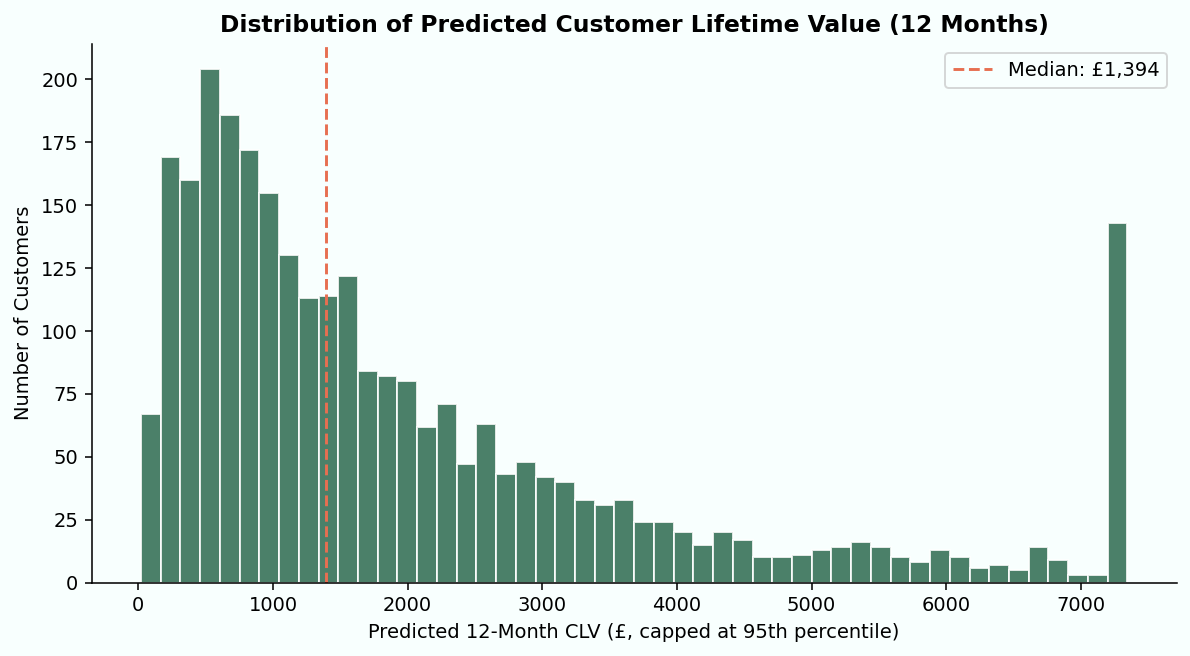

In [ ]:
#  CLV distribution 
fig, ax = plt.subplots(figsize=(10, 5))
clv_cap = gg_data['clv_12m'].clip(upper=gg_data['clv_12m'].quantile(0.95))
ax.hist(clv_cap, bins=50, color='#2D6A4F', edgecolor='white', alpha=0.85)
ax.set_xlabel('Predicted 12-Month CLV (£, capped at 95th percentile)')
ax.set_ylabel('Customers')
ax.set_title('Distribution of Predicted Customer Lifetime Value — Next 12 Months', fontsize=12, fontweight='bold')
median_clv = gg_data['clv_12m'].median()
ax.axvline(median_clv, color='#E76F51', linestyle='--', linewidth=1.5,
           label=f'Median: £{median_clv:,.0f}')
ax.legend()
plt.tight_layout()
plt.show()

The CLV distribution is sharply right-skewed: the median predicted value is £1,394 but the mean is £2,981, pulled up by a small cohort of high-frequency wholesale accounts the model correctly identifies as extremely valuable. The 95th-percentile cutoff in the chart hides this upper tail for visual clarity — the top customers have predicted 12-month values in the £50k–£400k range.

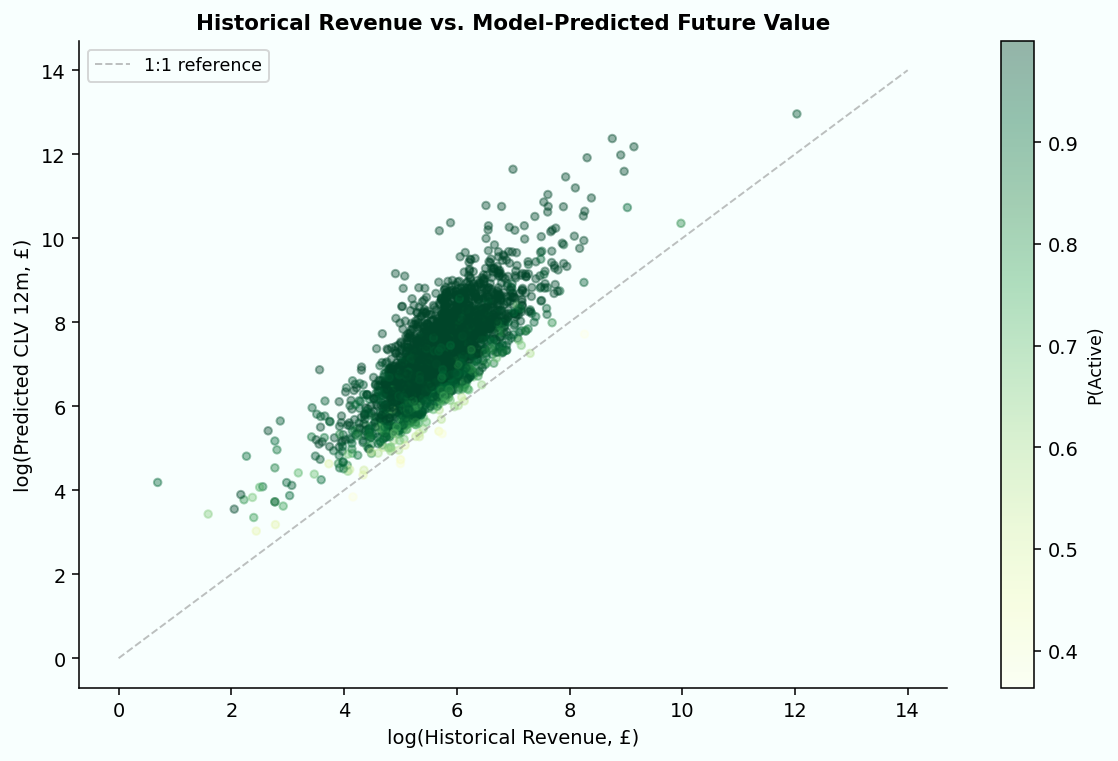

In [ ]:
#  Historical vs. predicted CLV scatter ─
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    np.log1p(gg_data['monetary_value']),
    np.log1p(gg_data['clv_12m']),
    c=gg_data['prob_alive'], cmap='YlGn', alpha=0.4, s=15
)
cb = plt.colorbar(sc, ax=ax); cb.set_label('P(Active)', fontsize=9)
ax.plot([0, 14], [0, 14], '--', color='grey', linewidth=1, alpha=0.5, label='1:1 reference')
ax.set_xlabel('log(Historical Revenue, £)')
ax.set_ylabel('log(Predicted CLV 12m, £)')
ax.set_title('Historical Revenue vs. Model-Predicted Future Value', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Points **above the 1:1 line** are customers the model expects to generate *more* forward revenue than their historical average implies — typically customers with high recency (recently purchased) and growing frequency. Points **below the line** are customers where the model is discounting forward revenue: buyers whose silence has grown long relative to their historical pace, or low-frequency customers whose historical spend per order was unusually high on a small sample.

This chart surfaces the most actionable customer-level insight from the model: identifying which historically modest customers have accelerating trajectories (above-line, high P(alive)) and which historically valuable customers may be decelerating.

In [ ]:
#  CLV quartile breakdown ─
gg_data['clv_quartile'] = pd.qcut(gg_data['clv_12m'], 4,
    labels=['Q1 — Lowest', 'Q2', 'Q3', 'Q4 — Highest'])

q_summary = gg_data.groupby('clv_quartile', observed=True).agg(
    Customers      = ('clv_12m',         'count'),
    Avg_Hist_Rev   = ('monetary_value',  'mean'),
    Avg_CLV_12m    = ('clv_12m',         'mean'),
    Avg_P_Alive    = ('prob_alive',      'mean'),
    Avg_Frequency  = ('frequency',       'mean'),
).round(1)

print("CLV Quartile Summary — Repeat Purchasers:")
print(q_summary.to_string())
print()
# Top 10 by predicted CLV
top = gg_data.nlargest(10, 'clv_12m')[
    ['frequency','recency','monetary_value','prob_alive','exp_purchases_90d','clv_12m']
].round(2)
print("Top 10 customers by predicted 12-month CLV:")
print(top.to_string())

CLV Quartile Summary — Repeat Purchasers:
                Customers  Avg_Hist_Rev  Avg_CLV_12m  Avg_P_Alive  Avg_Frequency
clv_quartile
Q1 — Lowest           698         162.1        402.4          0.9            1.6
Q2                    697         282.3       1000.9          1.0            2.7
Q3                    697         408.8       1943.9          1.0            4.1
Q4 — Highest          698        1049.9       8574.4          1.0            9.5

Top 10 customers by predicted 12-month CLV:
            frequency  recency  monetary_value  prob_alive  exp_purchases_90d    clv_12m
CustomerID
16446             1.0    205.0       168469.60        0.98               0.66  424708.16
14646            44.0    353.0        3737.80        1.00               9.90  236421.86
18102            25.0    367.0        9854.75        1.00               5.54  194381.07
17450            26.0    359.0        6229.24        1.00               5.75  159733.13
14096            16.0     97.0        9027

**Three patterns in the top-10 CLV table are worth noting:**

Customer **16446** tops the list at £424k predicted CLV despite having placed only 1 repeat order — because that single order was worth £168k. The model is essentially saying: *if this buyer is still active (P=0.98) and reorders at their historical rate, the forward value is enormous.* This is a candidate for direct account management contact to confirm their procurement cycle.

Customer **14911** presents the opposite profile: 131 orders at a modest £779 average. The model assigns them 27.8 expected purchases in the next 90 days — a near-continuous buyer whose value lies in frequency rather than per-order magnitude. Reliable, predictable, lower-risk revenue.

The **Q4 cohort** (698 customers) averages £8,574 predicted CLV against £1,050 historical revenue per period — the model is projecting forward based on high frequency and near-certain activity status. This group warrants investment in loyalty infrastructure (early stock access, volume pricing, dedicated account contacts) to protect what the model is predicting.

---
### Section Summary: What the Probabilistic Model Adds

| Question | RFM Answer | BG/NBD + GG Answer |
|---|---|---|
| Who is valuable now? | Champions segment | Supported — overlaps strongly |
| Who will be valuable in 12 months? | Approximated by segment | Explicit CLV estimate per customer |
| Who is likely to churn? | Inferred from recency tier | P(alive) — customer-specific probability |
| How many orders will this customer place? | Not modelled | Posterior estimate from purchase history |
| What is this customer worth to acquire/retain? | Not modelled | CLV estimate enables ROI calculation |

The BG/NBD model does not replace the RFM segmentation — both serve different audiences. The RFM view is intuitive and communicable to non-technical stakeholders. The probabilistic model is the right framework for budget allocation: if a win-back campaign costs £50 per customer and a reactivated customer's expected CLV is £1,400, the economics are clearly favourable even at a low reactivation rate. Without a CLV estimate, that calculation is guesswork.

**The aggregate predicted 12-month revenue from repeat buyers alone is £8.3M** — roughly matching the entire historical year. That is not a coincidence; it is the model reflecting the stability of a wholesale customer base with durable reorder patterns. For a business where relationship continuity is the primary revenue driver, that predictability is itself a competitive asset.